# Task 4: Coupled Plk4 and Cyclin/Cdk Oscillator Analysis



In [35]:
import os
os.environ["ARCHFLAGS"] = "-arch arm64"
os.environ["CFLAGS"] = "-mcpu=apple-m1"

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from jitcdde import jitcdde, y, t as dde_t

## 1. Helper functions and default parameters

In [36]:
def Hill_up(x, K, n):
    """Increasing Hill function."""
    return x**n / (K**n + x**n)


def Hill_full(x, basal, amp, K, n):
    """Increasing Hill function with basal level and amplitude."""
    return basal + amp * x**n / (K**n + x**n)


def Hill_dec(x, basal, amp, K, n):
    """Decreasing Hill function with basal level and amplitude."""
    return basal + amp * K**n / (K**n + x**n)

In [37]:
# Cdk/Cyclin oscillator parameters
ks_cyc = 1.5

deg_a, deg_b, deg_K, deg_n = 0.01, 0.06, 32.0, 17.0
cdc25_a, cdc25_b, cdc25_K, cdc25_n = 0.8, 4.0, 35.0, 11.0
wee1_a, wee1_b, wee1_K, wee1_n = 0.4, 2.0, 30.0, 3.5

# Plk4 oscillator parameters
ks_plk = 1.0
kd = 1.0
Kp = 1.0
n_plk = 8.0
tau = 18.0

# Coupling parameters
Ka = 30.0
m = 3.0
tau_cdk = 8.0  # delay between Cdk activity and its effect on Plk4 feedback

## 2. Core simulation function



In [ ]:
def run_simulation(
    epsilon=0.75,
    T=800,
    dt=0.1,
    P0=1.0,
    tau_val=tau,
    n_val=n_plk,
    ks_cyc_val=ks_cyc,
    kd_val=kd,
    ks_plk_val=ks_plk,
    Kp_val=Kp,
    tau_cdk_val=tau_cdk,
):
    """
    Simulate the coupled Cdk/Cyclin-Plk4 model.

    """

    c = y(0)  # total CyclinB
    a = y(1)  # active CyclinB/Cdk1
    P = y(2)  # Plk4

    P_delay = y(2, dde_t - tau_val)
    a_coupling = y(1, dde_t - tau_cdk_val)

    # Cdk/Cyclin oscillator
    dc_dt = ks_cyc_val - Hill_full(a, deg_a, deg_b, deg_K, deg_n) * c

    da_dt = (
        Hill_full(a, cdc25_a, cdc25_b, cdc25_K, cdc25_n) * (c - a)
        - Hill_dec(a, wee1_a, wee1_b, wee1_K, wee1_n) * a
        + ks_cyc_val
        - Hill_full(a, deg_a, deg_b, deg_K, deg_n) * a
    )

    # Coupling signal from Cdk/Cyclin to Plk4
    Phi_a = Hill_up(a_coupling, Ka, m)

    # Delayed Plk4 negative feedback
    HP_delay = Hill_up(P_delay, Kp_val, n_val)

    # Cdk/Cyclin activity reduces the delayed Plk4 negative feedback
    feedback_factor = 1.0 - epsilon * Phi_a

    dP_dt = ks_plk_val - kd_val * P - kd_val * P * HP_delay * feedback_factor

    dde = jitcdde([dc_dt, da_dt, dP_dt])
    dde.constant_past([55.0, 25.0, P0])
    dde.step_on_discontinuities()

    times = np.arange(dde.t, T + dt, dt)
    values = np.array([dde.integrate(time_point) for time_point in times])

    c_vals = values[:, 0]
    a_vals = values[:, 1]
    P_vals = values[:, 2]

    # This is the observed coupling signal based on the simulated active Cdk/Cyclin level.
    # It is shown for plotting only
    Phi_vals = Hill_up(a_vals, Ka, m)

    return times, c_vals, a_vals, P_vals, Phi_vals

## 3. Phase-locking 



In [39]:
def calculate_phase_lags(times, a_vals, P_vals, start_time=300, cdk_prominence=10):
    """
    Return Plk4 phase lags measured relative to each Cdk/Cyclin cycle.
    The phase lag is normalized by the corresponding Cdk/Cyclin period.
    """

    mask = times >= start_time
    t_late = times[mask]
    a_late = a_vals[mask]
    P_late = P_vals[mask]

    cdk_peaks, _ = find_peaks(a_late, prominence=cdk_prominence)

    if len(cdk_peaks) < 4:
        return np.array([]), np.array([])

    cdk_peak_times = t_late[cdk_peaks]
    phase_lags = []
    cycle_numbers = []

    for i in range(len(cdk_peak_times) - 1):
        t_start = cdk_peak_times[i]
        t_end = cdk_peak_times[i + 1]
        cycle_period = t_end - t_start

        cycle_mask = (t_late >= t_start) & (t_late < t_end)
        if np.sum(cycle_mask) == 0:
            continue

        t_cycle = t_late[cycle_mask]
        P_cycle = P_late[cycle_mask]
        plk4_peak_time = t_cycle[np.argmax(P_cycle)]

        phase_lag = (plk4_peak_time - t_start) / cycle_period
        phase_lags.append(phase_lag)
        cycle_numbers.append(i + 1)

    return np.array(cycle_numbers), np.array(phase_lags)


def calculate_phase_lag_stats(times, a_vals, P_vals, start_time=300):
    cycle_numbers, phase_lags = calculate_phase_lags(times, a_vals, P_vals, start_time=start_time)

    if len(phase_lags) < 3:
        return np.nan, np.nan, len(phase_lags)

    return np.mean(phase_lags), np.std(phase_lags), len(phase_lags)


def estimate_cdk_period(times, a_vals, start_time=300, cdk_prominence=10):
    mask = times >= start_time
    t_late = times[mask]
    a_late = a_vals[mask]

    cdk_peaks, _ = find_peaks(a_late, prominence=cdk_prominence)
    if len(cdk_peaks) < 4:
        return np.nan

    cdk_peak_times = t_late[cdk_peaks]
    return np.mean(np.diff(cdk_peak_times))

## 4. Baseline coupled and uncoupled simulations

Generating, compiling, and loading C code.
Using default integration parameters.
Generating, compiling, and loading C code.


/var/folders/43/0y2503ss7c9fq6rz4gj0v7rw0000gn/T/ipykernel_56759/3654436808.py:54: UserWarning: The target time is smaller than the current time. No integration step will happen. The returned state will be extrapolated from the interpolating Hermite polynomial for the last integration step. You may see this because you try to integrate backwards in time, in which case you did something wrong. You may see this just because your sampling step is small, in which case there is no need to worry (though you should think about increasing your sampling time).
  values = np.array([dde.integrate(time_point) for time_point in times])


Using default integration parameters.


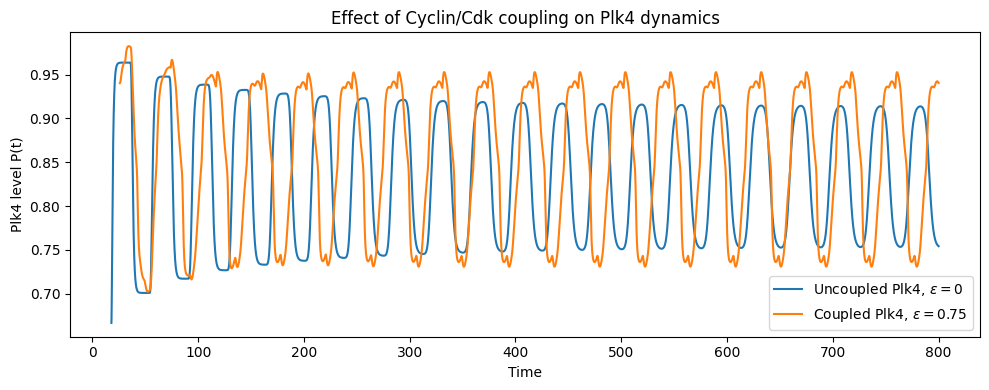

In [40]:
times_unc, c_unc, a_unc, P_unc, Phi_unc = run_simulation(epsilon=0.0, T=800, dt=0.1)
times_coup, c_coup, a_coup, P_coup, Phi_coup = run_simulation(epsilon=0.75, T=800, dt=0.1)

plt.figure(figsize=(10, 4))
plt.plot(times_unc, P_unc, label=r"Uncoupled Plk4, $\epsilon=0$")
plt.plot(times_coup, P_coup, label=r"Coupled Plk4, $\epsilon=0.75$")
plt.xlabel("Time")
plt.ylabel("Plk4 level P(t)")
plt.title("Effect of Cyclin/Cdk coupling on Plk4 dynamics")
plt.legend()
plt.tight_layout()
plt.show()

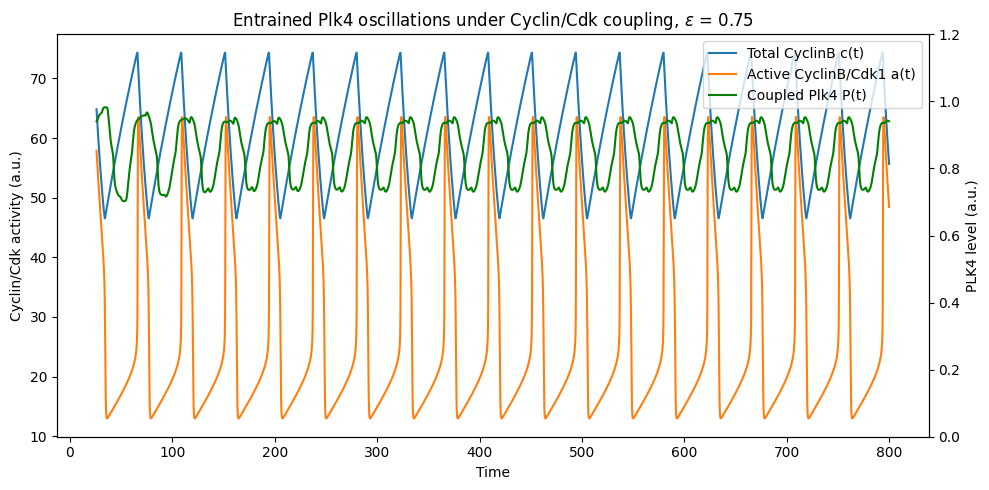

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(times_coup, c_coup, label="Total CyclinB c(t)")
ax1.plot(times_coup, a_coup, label="Active CyclinB/Cdk1 a(t)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Cyclin/Cdk activity (a.u.)")

ax2 = ax1.twinx()
ax2.set_ylim(0, 1.2)
ax2.plot(times_coup, P_coup, color="green", label="Coupled Plk4 P(t)")
ax2.set_ylabel("PLK4 level (a.u.)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Entrained Plk4 oscillations under Cyclin/Cdk coupling, $\\epsilon$ = 0.75")
plt.tight_layout()
plt.show()

Generating, compiling, and loading C code.
Using default integration parameters.
Generating, compiling, and loading C code.


/var/folders/43/0y2503ss7c9fq6rz4gj0v7rw0000gn/T/ipykernel_56759/3654436808.py:54: UserWarning: The target time is smaller than the current time. No integration step will happen. The returned state will be extrapolated from the interpolating Hermite polynomial for the last integration step. You may see this because you try to integrate backwards in time, in which case you did something wrong. You may see this just because your sampling step is small, in which case there is no need to worry (though you should think about increasing your sampling time).
  values = np.array([dde.integrate(time_point) for time_point in times])


Using default integration parameters.
Generating, compiling, and loading C code.
Using default integration parameters.


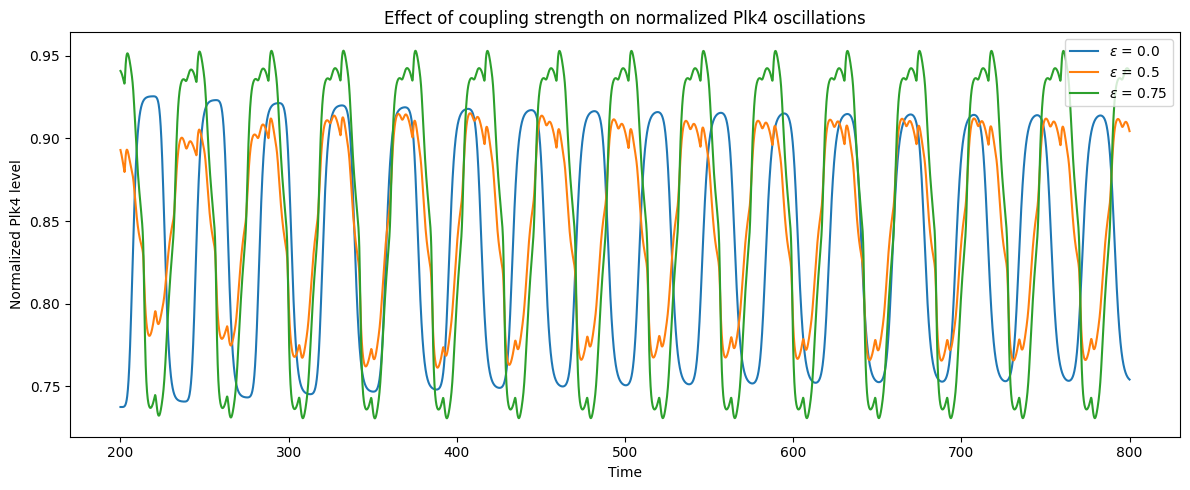

In [42]:
epsilon_values = [0.0, 0.5, 0.75]

plt.figure(figsize=(12, 5))

for eps in epsilon_values:

    times, c_vals, a_vals, P_vals, Phi_vals = run_simulation(epsilon=eps)

    # remove transient
    mask = times >= 200
    t_plot = times[mask]
    P_plot = P_vals[mask]


    plt.plot(
        t_plot,
        P_plot,
        label=f"$\\epsilon$ = {eps}"
    )

plt.xlabel("Time")
plt.ylabel("Normalized Plk4 level")
plt.title("Effect of coupling strength on normalized Plk4 oscillations")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
from scipy.signal import find_peaks
import numpy as np

# remove transient
mask = times >= 200
t = times[mask]
a = a_vals[mask]
P = P_vals[mask]

# detect peaks
cdk_peaks, _ = find_peaks(a, prominence=5)
plk4_peaks, _ = find_peaks(P, prominence=0.02)

t_cdk = t[cdk_peaks]
t_plk4 = t[plk4_peaks]

locking_ratio = len(t_plk4) / len(t_cdk)

print("Number of Cdk peaks:", len(t_cdk))
print("Number of Plk4 peaks:", len(t_plk4))
print("Locking ratio:", locking_ratio)

phase_lags = []

for i in range(min(len(t_cdk), len(t_plk4))):

    lag = t_plk4[i] - t_cdk[i]
    phase_lags.append(lag)

phase_lags = np.array(phase_lags)

print("Mean phase lag:", np.mean(phase_lags))
print("Std phase lag:", np.std(phase_lags))

Number of Cdk peaks: 14
Number of Plk4 peaks: 13
Locking ratio: 0.9285714285714286
Mean phase lag: 8.88461538461551
Std phase lag: 0.03608012122939869


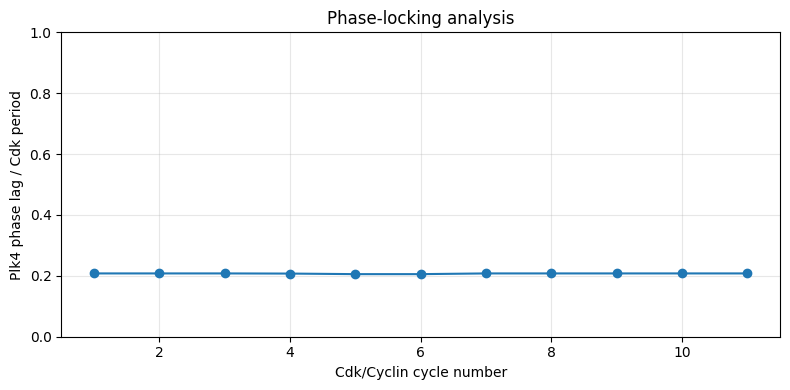

Mean phase lag: 0.20747505114539938
Standard deviation of phase lag: 0.0008911006170795955


In [44]:
cycle_numbers, phase_lags = calculate_phase_lags(times_coup, a_coup, P_coup, start_time=300)

plt.figure(figsize=(8, 4))
plt.plot(cycle_numbers, phase_lags, "o-")
plt.xlabel("Cdk/Cyclin cycle number")
plt.ylabel("Plk4 phase lag / Cdk period")
plt.title("Phase-locking analysis")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean phase lag:", np.mean(phase_lags))
print("Standard deviation of phase lag:", np.std(phase_lags))

## 5. Robustness under measurement noise

This analysis adds noise after simulation.

Generating, compiling, and loading C code.
Using default integration parameters.


/var/folders/43/0y2503ss7c9fq6rz4gj0v7rw0000gn/T/ipykernel_56759/3654436808.py:54: UserWarning: The target time is smaller than the current time. No integration step will happen. The returned state will be extrapolated from the interpolating Hermite polynomial for the last integration step. You may see this because you try to integrate backwards in time, in which case you did something wrong. You may see this just because your sampling step is small, in which case there is no need to worry (though you should think about increasing your sampling time).
  values = np.array([dde.integrate(time_point) for time_point in times])


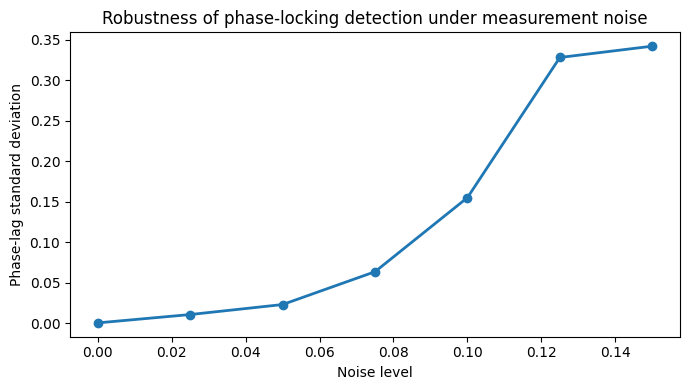

In [45]:
def add_measurement_noise(signal, noise_level):
    amplitude = np.max(signal) - np.min(signal)
    noise = np.random.normal(0, noise_level * amplitude, size=len(signal))
    return signal + noise


def phase_locking_under_noise(
    epsilon=0.75,
    tau_val=tau,
    noise_levels=np.linspace(0, 0.15, 7),
    n_repeats=30,
    T=800,
    dt=0.1,
    start_time=300,
):
    """
    Add measurement noise to the simulated Cdk/Cyclin and Plk4 traces and
    quantify whether the calculated phase lag remains stable.
    """

    times, c_vals, a_vals, P_vals, Phi_vals = run_simulation(
        epsilon=epsilon,
        tau_val=tau_val,
        T=T,
        dt=dt,
    )

    results = []

    for noise_level in noise_levels:
        mean_lag_values = []
        phase_std_values = []

        for repeat in range(n_repeats):
            a_noisy = add_measurement_noise(a_vals, noise_level)
            P_noisy = add_measurement_noise(P_vals, noise_level)

            # Light smoothing helps avoid false peaks caused only by noise.
            a_noisy = gaussian_filter1d(a_noisy, sigma=2)
            P_noisy = gaussian_filter1d(P_noisy, sigma=2)

            mean_lag, std_lag, n_cycles = calculate_phase_lag_stats(
                times,
                a_noisy,
                P_noisy,
                start_time=start_time,
            )

            if np.isfinite(std_lag):
                mean_lag_values.append(mean_lag)
                phase_std_values.append(std_lag)

        results.append([
            noise_level,
            np.nanmean(mean_lag_values),
            np.nanstd(mean_lag_values),
            np.nanmean(phase_std_values),
            np.nanstd(phase_std_values),
        ])

    results = np.array(results)

    plt.figure(figsize=(7, 4))
    plt.plot(results[:, 0], results[:, 3], marker="o", linewidth=2)
    plt.xlabel("Noise level")
    plt.ylabel("Phase-lag standard deviation")
    plt.title("Robustness of phase-locking detection under measurement noise")
    plt.tight_layout()
    plt.show()

    return results


noise_results = phase_locking_under_noise(
    epsilon=0.75,
    tau_val=18.0,
    noise_levels=np.linspace(0, 0.15, 7),
    n_repeats=30,
)

##  Effect of Cdk/Cyclin oscillation frequency



Generating, compiling, and loading C code.
Using default integration parameters.
ks_cyc=0.7: Cdk period=nan, mean lag=nan, std lag=nan, cycles=0
Generating, compiling, and loading C code.


/var/folders/43/0y2503ss7c9fq6rz4gj0v7rw0000gn/T/ipykernel_56759/3654436808.py:54: UserWarning: The target time is smaller than the current time. No integration step will happen. The returned state will be extrapolated from the interpolating Hermite polynomial for the last integration step. You may see this because you try to integrate backwards in time, in which case you did something wrong. You may see this just because your sampling step is small, in which case there is no need to worry (though you should think about increasing your sampling time).
  values = np.array([dde.integrate(time_point) for time_point in times])


Using default integration parameters.
ks_cyc=0.85: Cdk period=132.1750000000019, mean lag=0.07527849323336185, std lag=0.0017122422793845256, cycles=4
Generating, compiling, and loading C code.
Using default integration parameters.
ks_cyc=1.0: Cdk period=81.87142857142973, mean lag=0.10818335233284562, std lag=0.0005623660137018641, cycles=7
Generating, compiling, and loading C code.
Using default integration parameters.
ks_cyc=1.15: Cdk period=61.91250000000088, mean lag=0.21885715774662573, std lag=0.0007711299481656511, cycles=8
Generating, compiling, and loading C code.
Using default integration parameters.
ks_cyc=1.3: Cdk period=51.12000000000072, mean lag=0.21185405454990208, std lag=0.000776989875545559, cycles=10
Generating, compiling, and loading C code.
Using default integration parameters.
ks_cyc=1.5: Cdk period=42.81538461538522, mean lag=0.20733017282262425, std lag=0.000958760518361142, cycles=13


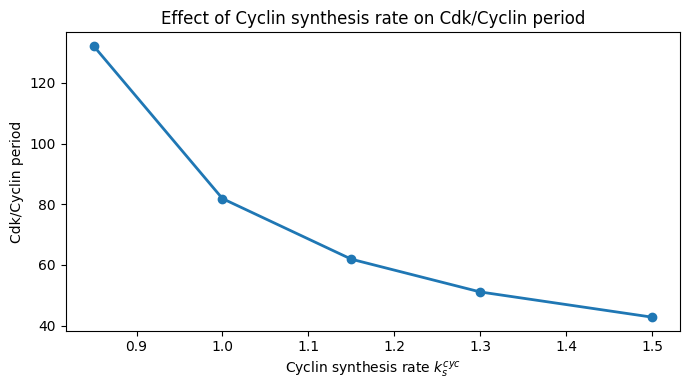

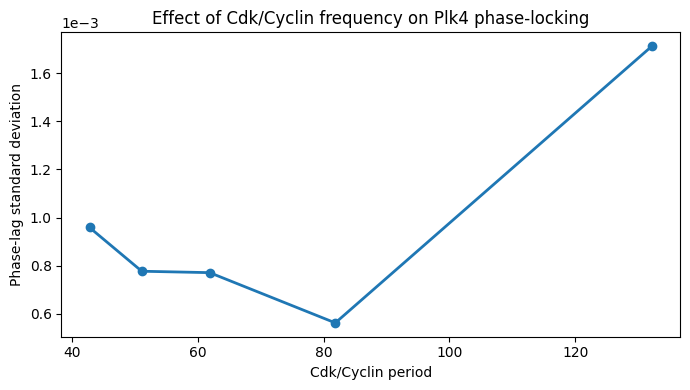

In [46]:
def cdk_frequency_analysis():
    ks_cyc_values = np.array([0.7, 0.85, 1.0, 1.15, 1.3, 1.5])

    cdk_period_values = []
    phase_mean_values = []
    phase_std_values = []
    n_cycles_values = []

    for ks_test in ks_cyc_values:
        times, c_vals, a_vals, P_vals, Phi_vals = run_simulation(
            epsilon=0.75,
            T=900,
            dt=0.1,
            ks_cyc_val=ks_test,
        )

        mean_lag, std_lag, n_cycles = calculate_phase_lag_stats(
            times,
            a_vals,
            P_vals,
            start_time=300,
        )

        cdk_period = estimate_cdk_period(times, a_vals, start_time=300)

        cdk_period_values.append(cdk_period)
        phase_mean_values.append(mean_lag)
        phase_std_values.append(std_lag)
        n_cycles_values.append(n_cycles)

        print(
            f"ks_cyc={ks_test}: Cdk period={cdk_period}, "
            f"mean lag={mean_lag}, std lag={std_lag}, cycles={n_cycles}"
        )

    cdk_period_values = np.array(cdk_period_values)
    phase_mean_values = np.array(phase_mean_values)
    phase_std_values = np.array(phase_std_values)
    n_cycles_values = np.array(n_cycles_values)

    plt.figure(figsize=(7, 4))
    plt.plot(ks_cyc_values, cdk_period_values, marker="o", linewidth=2)
    plt.xlabel(r"Cyclin synthesis rate $k_s^{cyc}$")
    plt.ylabel("Cdk/Cyclin period")
    plt.title("Effect of Cyclin synthesis rate on Cdk/Cyclin period")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(cdk_period_values, phase_std_values, marker="o", linewidth=2)
    plt.xlabel("Cdk/Cyclin period")
    plt.ylabel("Phase-lag standard deviation")
    plt.title("Effect of Cdk/Cyclin frequency on Plk4 phase-locking")
    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    plt.tight_layout()
    plt.show()

    return ks_cyc_values, cdk_period_values, phase_mean_values, phase_std_values, n_cycles_values


ks_cyc_values, cdk_period_values, phase_mean_values, phase_std_values, n_cycles_values = cdk_frequency_analysis()